# 03 — LDA Topic Modeling with Gensim

Build the dictionary and Bag-of-Words corpus, compare topic counts with coherence, train the final model, and save artifacts for Flask.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

df=pd.read_pickle("../data/ag_news_preprocessed.pkl")
texts=df["tokens"].tolist()
dictionary=Dictionary(texts)
dictionary.filter_extremes(no_below=10,no_above=0.5,keep_n=50000)
corpus=[dictionary.doc2bow(text) for text in texts]
print("Documents:",len(corpus),"Vocabulary:",len(dictionary))

Documents: 120000 Vocabulary: 18288


In [2]:
candidate_topics=[4,6,8,10,12]
coherence_scores=[]
for k in candidate_topics:
    model=LdaModel(corpus=corpus,id2word=dictionary,num_topics=k,random_state=42,passes=5,iterations=100,alpha="auto",eta="auto")
    score=CoherenceModel(model=model,texts=texts,dictionary=dictionary,coherence="c_v").get_coherence()
    coherence_scores.append(score)
    print(f"{k} topics -> coherence={score:.4f}")

4 topics -> coherence=0.3880
6 topics -> coherence=0.4941
8 topics -> coherence=0.4665
10 topics -> coherence=0.4821
12 topics -> coherence=0.4703


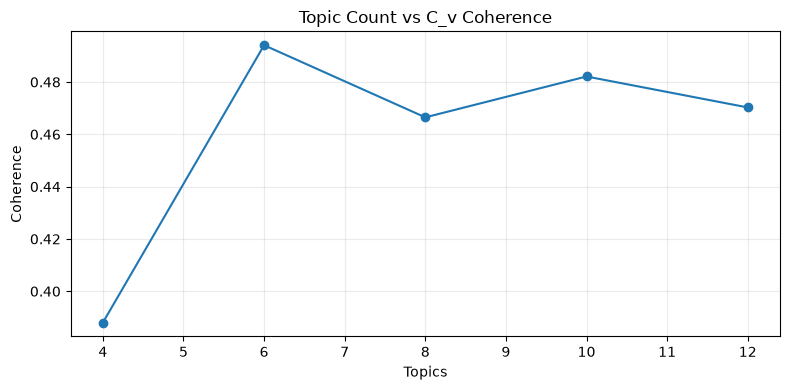

In [3]:
plt.figure(figsize=(8,4)); plt.plot(candidate_topics,coherence_scores,marker="o")
plt.title("Topic Count vs C_v Coherence"); plt.xlabel("Topics"); plt.ylabel("Coherence"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

In [4]:
best_k=candidate_topics[coherence_scores.index(max(coherence_scores))]
print("Selected:",best_k)
lda_model=LdaModel(corpus=corpus,id2word=dictionary,num_topics=best_k,random_state=42,passes=10,iterations=150,alpha="auto",eta="auto")
for topic_id,terms in lda_model.show_topics(num_topics=best_k,num_words=12,formatted=False):
    print(f"Topic {topic_id+1}: "+", ".join(w for w,_ in terms))

Selected: 6
Topic 1: said, united, president, court, yesterday, says, former, chief, states, bush, washington, european
Topic 2: reuters, oil, percent, said, prices, china, new, york, year, sales, thursday, friday
Topic 3: said, iraq, minister, reuters, killed, people, leader, prime, police, two, palestinian, iraqi
Topic 4: game, first, season, night, team, last, coach, win, world, points, second, victory
Topic 5: new, years, next, one, may, year, first, two, now, time, mobile, today
Topic 6: company, inc, new, microsoft, corp, million, software, said, search, internet, announced, business


In [5]:
lda_model.save("../models/lda_model.gensim")
dictionary.save("../models/news_dictionary.gensim")
print("Model artifacts saved.")

Model artifacts saved.
